In [2]:
import SimpleITK as sitk
import numpy as np 
import matplotlib.pyplot as plt 

img_sitk = sitk.ReadImage('../../3702_left_knee.nii') 
img_sitk

<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'itk::simple::Image *' at 0x000001FE2DD32610> >

In [3]:
#Converting sitk_metadata to image Array
image = sitk.GetArrayFromImage(img_sitk) 
image.shape 

(216, 512, 512)

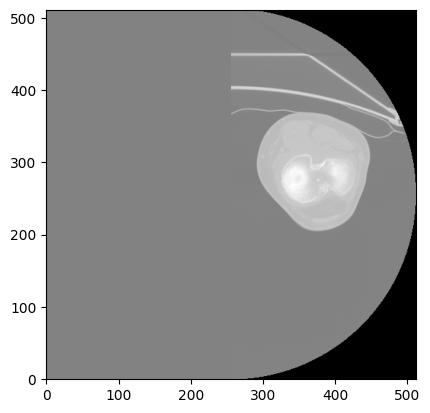

In [4]:
plt.imshow(np.squeeze(image[100, :, :]), cmap='gray',origin='lower');
plt.show()

In [5]:
print(f"Image Dimensions: {img_sitk.GetSize()}")
print(f"Voxel Spacing: {img_sitk.GetSpacing()}")
print(f"Image Origin: {img_sitk.GetOrigin()}")

# Easier to read as a 3x3 matrix
print(f"Image Direction (Orientation): \n{np.array(img_sitk.GetDirection()).reshape(3,3)}") 
print(f"Pixel ID Type: {img_sitk.GetPixelIDTypeAsString()}") 

Image Dimensions: (512, 512, 216)
Voxel Spacing: (0.8691409826278687, 0.8691409826278687, 2.0)
Image Origin: (-222.5, -222.5, -900.5)
Image Direction (Orientation): 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Pixel ID Type: 32-bit signed integer


In [ ]:
def show_slice(slice_data, title='Slice', cmap='gray'):
	plt.figure(figsize=(6, 6))
	plt.imshow(slice_data, cmap=cmap, origin='lower')
	plt.title(title)
	plt.axis('off') 
	plt.show()

In [7]:
depth, height, width = image.shape 
print(depth, height, width)

216 512 512


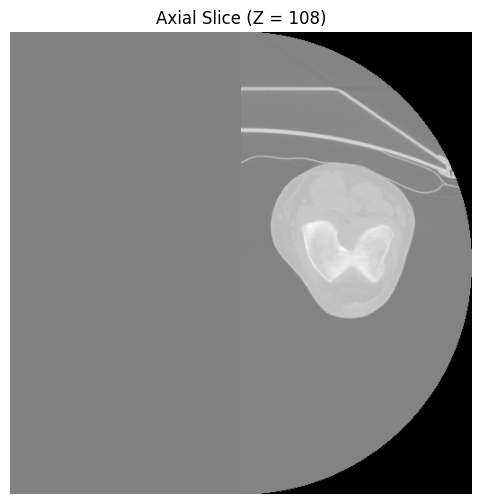

In [8]:
# axial view 
axial_slice_index = depth // 2
axial_slice = image[axial_slice_index, :, :]
show_slice(axial_slice, title=f'Axial Slice (Z = {axial_slice_index})')

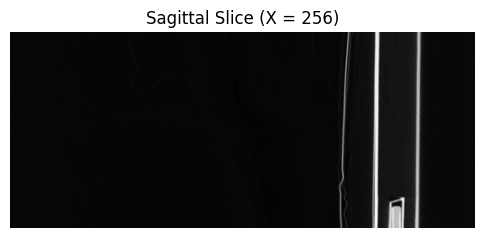

In [9]:
# sagittal view 
sagittal_slice_index = width // 2
sagittal_slice = image[:, :, sagittal_slice_index]
show_slice(sagittal_slice, title=f'Sagittal Slice (X = {sagittal_slice_index})')

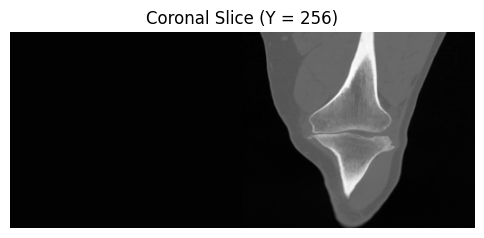

In [10]:
# coronal view 
coronal_slice_index = height // 2
coronal_slice = image[:, coronal_slice_index+1, :]
show_slice(coronal_slice, title=f'Coronal Slice (Y = {coronal_slice_index})')

### Segmentation

In [11]:
from skimage import measure
from scipy.ndimage import gaussian_filter1d
import cv2 

In [25]:
threshold_value = 190  

# thresholding
bone_mask = (coronal_slice > threshold_value).astype(np.uint8)

# cleanup
kernel = np.ones((7, 7), np.uint8)
bone_mask = cv2.morphologyEx(bone_mask, cv2.MORPH_CLOSE, kernel)
bone_mask = cv2.morphologyEx(bone_mask, cv2.MORPH_OPEN, kernel)

# for all slices of 3d image
bone_mask_3d = (image > threshold_value).astype(np.uint8)
bone_mask_3d = cv2.morphologyEx(bone_mask_3d, cv2.MORPH_CLOSE, kernel)
bone_mask_3d = cv2.morphologyEx(bone_mask_3d, cv2.MORPH_OPEN, kernel)

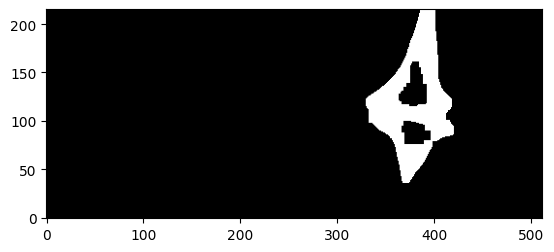

In [13]:
plt.imshow(bone_mask, cmap='gray', origin='lower')

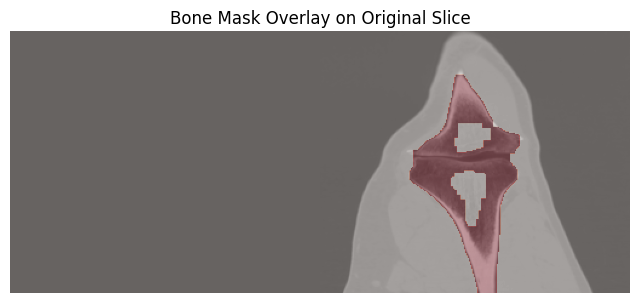

In [14]:
plt.figure(figsize=(8, 8))
plt.imshow(coronal_slice, cmap='gray')
plt.imshow(bone_mask, cmap='Reds', alpha=0.4)  # red overlay with transparency
plt.title("Bone Mask Overlay on Original Slice")
plt.axis('off')
plt.show()

### Expansion 

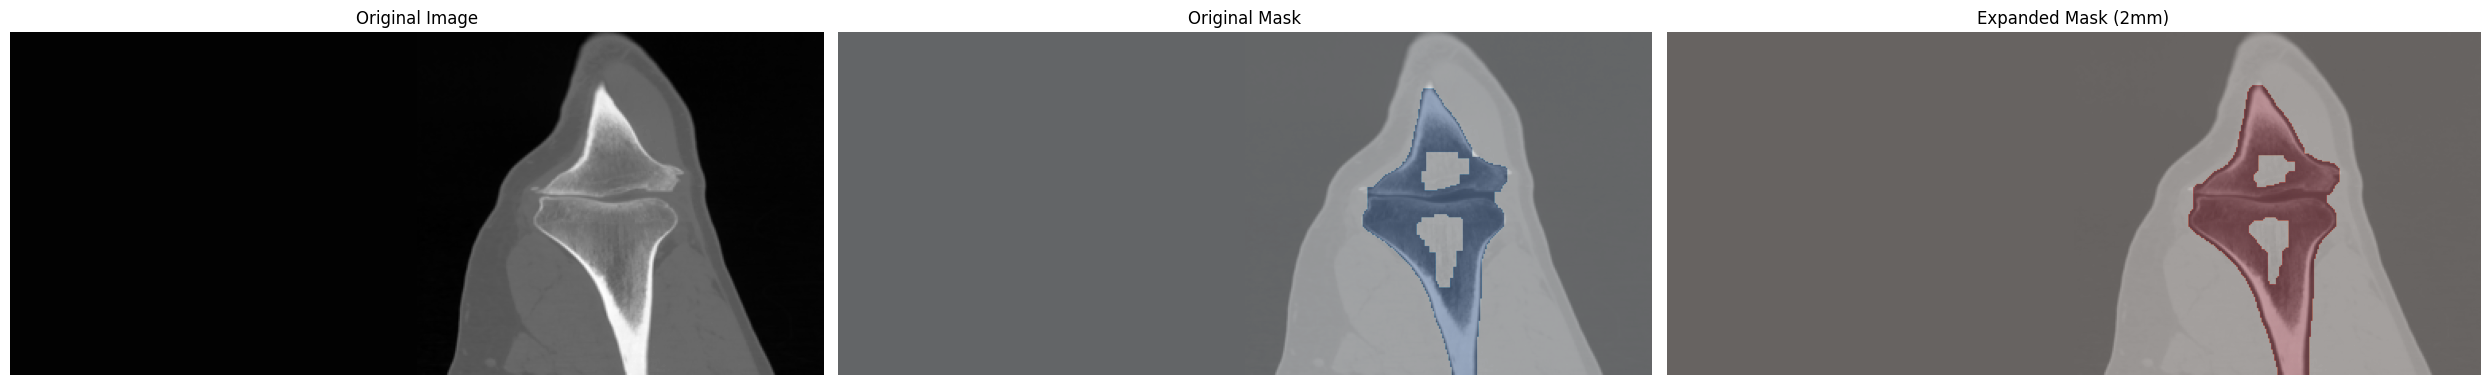

In [ ]:
spacing = img_sitk.GetSpacing() # Get the spacing of the image

pixel_size = spacing[0]  
dilation_radius_mm = 2
dilation_radius_pixels = int(dilation_radius_mm / pixel_size)

from skimage.morphology import disk, dilation

structuring_element = disk(dilation_radius_pixels)
expanded_mask = dilation(bone_mask, structuring_element)

plt.figure(figsize=(25, 16))

plt.subplot(1, 3, 1)
plt.imshow(coronal_slice, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(coronal_slice, cmap='gray')
plt.imshow(bone_mask, cmap='Blues', alpha=0.4)
plt.title("Original Mask")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(coronal_slice, cmap='gray')
plt.imshow(expanded_mask, cmap='Reds', alpha=0.4)
plt.title("Expanded Mask (2mm)")
plt.axis('off')

plt.tight_layout()
plt.show()


### Randomized variation of the contour

In [17]:
bone_mask.shape, bone_mask_3d.shape

((216, 512), (216, 512, 512))

In [ ]:
from skimage.morphology import ball, dilation

def generate_randomized_mask_3d(bone_mask_3d, spacing_mm=(1.0, 1.0, 1.0), max_expansion_mm=2.0, randomness=0.5):
	avg_spacing = np.mean(spacing_mm)
	radius_voxels = int(np.ceil(max_expansion_mm / avg_spacing))
	struct_element = ball(radius_voxels)
	expanded_mask = dilation(bone_mask_3d, struct_element)
	boundary_region = (expanded_mask == 1) & (bone_mask_3d == 0)
	random_addition = np.zeros_like(bone_mask_3d)
	boundary_indices = np.argwhere(boundary_region)
	num_voxels_to_keep = int(len(boundary_indices) * randomness)
	if num_voxels_to_keep > 0:
		selected_indices = boundary_indices[
			np.random.choice(len(boundary_indices), num_voxels_to_keep, replace=False)
		]
		for z, y, x in selected_indices:
			random_addition[z, y, x] = 1
	randomized_mask = np.logical_or(bone_mask_3d, random_addition).astype(np.uint8)
	return randomized_mask

random_mask = generate_randomized_mask_3d(bone_mask_3d, spacing_mm=img_sitk.GetSpacing())

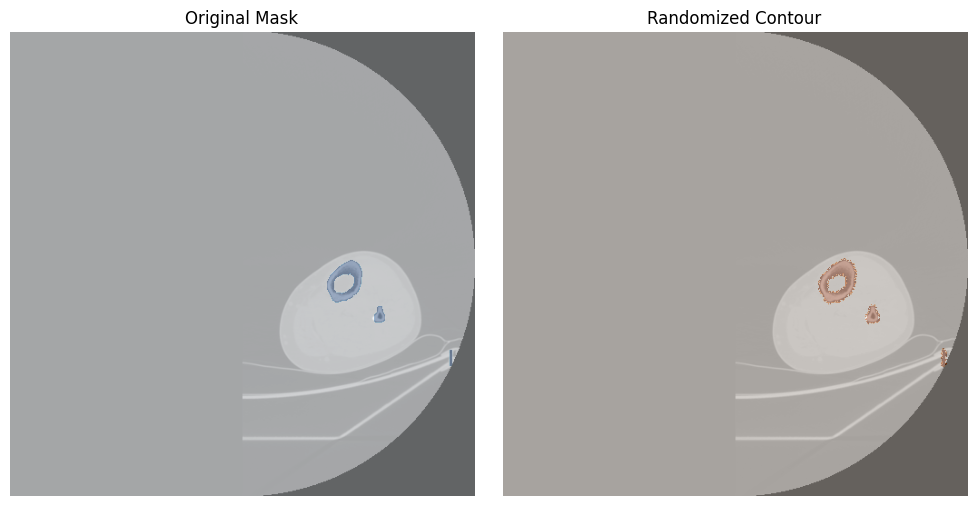

In [19]:
import matplotlib.pyplot as plt

z_slice = 50  
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image[z_slice], cmap='gray')
plt.imshow(bone_mask_3d[z_slice], cmap='Blues', alpha=0.4)
plt.title("Original Mask")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image[z_slice], cmap='gray')
plt.imshow(random_mask[z_slice], cmap='Oranges', alpha=0.4)
plt.title("Randomized Contour")
plt.axis('off')

plt.tight_layout()
plt.show()

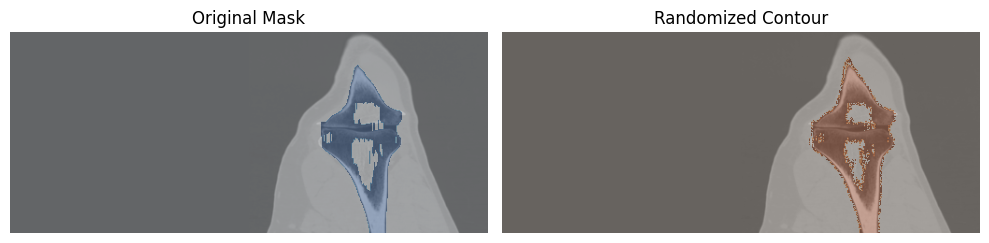

In [20]:
import matplotlib.pyplot as plt

z_slice = 50  # choose a slice
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image[:, coronal_slice_index, :], cmap='gray')
plt.imshow(bone_mask_3d[:, coronal_slice_index, :], cmap='Blues', alpha=0.4)
plt.title("Original Mask")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image[:, coronal_slice_index, :], cmap='gray')
plt.imshow(random_mask[:, coronal_slice_index, :], cmap='Oranges', alpha=0.4)
plt.title("Randomized Contour")
plt.axis('off')

plt.tight_layout()
plt.show()

### Detection points 

In [ ]:
def get_medial_lateral_lowest_points(mask_3d):
	
	# non zero means the bone surface based on segmentation
	z_indices = np.where(mask_3d.any(axis=(1, 2)))[0]
	if len(z_indices) == 0:
		return None, None

	# the most bottom slice with bone surface
	lowest_z = z_indices[-1]
	slice_mask = mask_3d[lowest_z]
	
	coords = np.argwhere(slice_mask)
	
	if coords.shape[0] == 0:
		return None, None
	
	coords_sorted = coords[np.argsort(coords[:, 1])]

	# medial and lateral points are the first and last in sorted order
	medial = (lowest_z, coords_sorted[0][0], coords_sorted[0][1])
	lateral = (lowest_z, coords_sorted[-1][0], coords_sorted[-1][1])
	return medial, lateral

def visualize_mask(mask_3d, title, point1=None, point2=None):
	z = mask_3d.shape[0] // 2
	slice_ = mask_3d[z]
	plt.figure(figsize=(6, 6))
	plt.imshow(slice_, cmap='gray')
	if point1: plt.plot(point1[2], point1[1], 'ro')
	if point2: plt.plot(point2[2], point2[1], 'bo')
	plt.title(title)
	plt.axis('off')
	plt.show()

# voxel spacing 
spacing_mm=img_sitk.GetSpacing()

expanded_2mm = dilation(bone_mask_3d, ball(int(2 / spacing_mm[0])))
expanded_4mm = dilation(bone_mask_3d, ball(int(4 / spacing_mm[0])))

random_mask_1 = generate_randomized_mask_3d(bone_mask_3d, spacing_mm, 2.0, 0.6)
random_mask_2 = generate_randomized_mask_3d(bone_mask_3d, spacing_mm, 4.0, 0.8)


Original → Medial: (215, 236, 379), Lateral: (215, 357, 486)


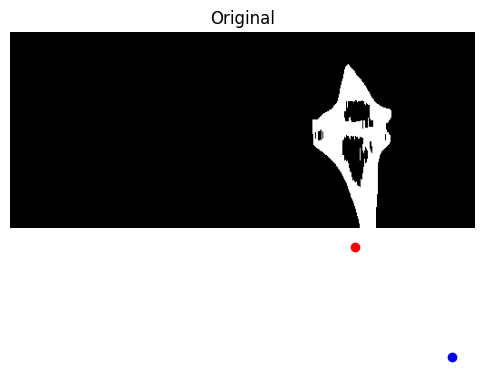

Expanded 2mm → Medial: (215, 235, 377), Lateral: (215, 355, 488)


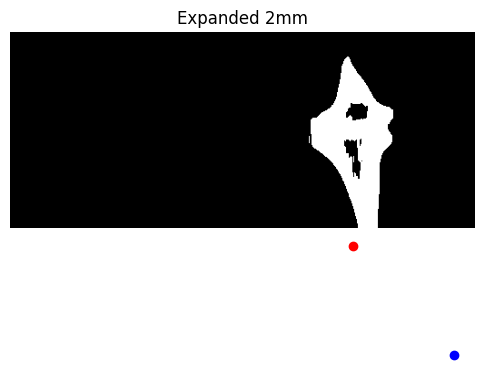

Expanded 4mm → Medial: (215, 235, 375), Lateral: (215, 354, 490)


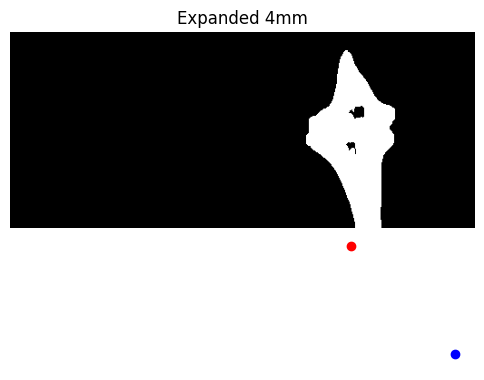

Randomized 2mm → Medial: (215, 243, 377), Lateral: (215, 358, 488)


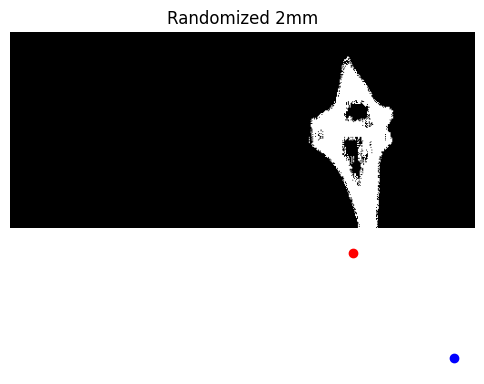

Randomized 4mm → Medial: (215, 236, 375), Lateral: (215, 355, 490)


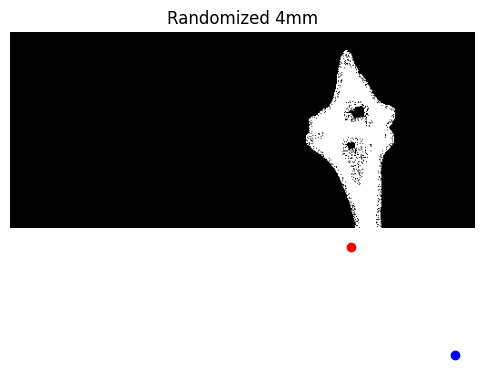

In [ ]:
masks = {
	"Original": bone_mask_3d,
	"Expanded 2mm": expanded_2mm,
	"Expanded 4mm": expanded_4mm,
	"Randomized 2mm": random_mask_1,
	"Randomized 4mm": random_mask_2
}

def visualize_mask(mask_3d, title, point1=None, point2=None):
	slice_ = mask_3d[:, coronal_slice_index, :]
	
	plt.figure(figsize=(6, 6))
	plt.imshow(slice_, cmap='gray')
	if point1: plt.plot(point1[2], point1[1], 'ro')
	if point2: plt.plot(point2[2], point2[1], 'bo')
	plt.title(title)
	plt.axis('off')
	plt.show()

for name, mask in masks.items():
	medial, lateral = get_medial_lateral_lowest_points(mask)
	print(f"{name} → Medial: {medial}, Lateral: {lateral}")
	visualize_mask(mask, title=name, point1=medial, point2=lateral)